# Dữ đoán giá nhà

Data fields
Here's a brief version of what you'll find in the data description file.<br>
- `SalePrice` - the property's sale price in dollars. This is the target variable that you're trying to predict.
- `MSSubClass`: The building class
- `MSZoning`: The general zoning classification
- `LotFrontage`: Linear feet of street connected to property
- `LotArea`: Lot size in square feet
- `Street`: Type of road access
- `Alley`: Type of alley access
- `LotShape`: General shape of property
- `LandContour`: Flatness of the property
- `Utilities`: Type of utilities available
- `LotConfig`: Lot configuration
- `LandSlope`: Slope of property
- `Neighborhood`: Physical locations within Ames city limits
- `Condition1`: Proximity to main road or railroad
- `Condition2`: Proximity to main road or railroad (if a second is present)
- `BldgType`: Type of dwelling
- `HouseStyle`: Style of dwelling
- `OverallQual`: Overall material and finish quality
- `OverallCond`: Overall condition rating
- `YearBuilt`: Original construction date
- `YearRemodAdd`: Remodel date
- `RoofStyle`: Type of roof
- `RoofMatl`: Roof material
- `Exterior1st`: Exterior covering on house
- `Exterior2nd`: Exterior covering on house (if more than one material)
- `MasVnrType`: Masonry veneer type
- `MasVnrArea`: Masonry veneer area in square feet
- `ExterQual`: Exterior material quality
- `ExterCond`: Present condition of the material on the exterior
- `Foundation`: Type of foundation
- `BsmtQual`: Height of the basement
- `BsmtCond`: General condition of the basement
- `BsmtExposure`: Walkout or garden level basement walls
- `BsmtFinType1`: Quality of basement finished area
- `BsmtFinSF1`: Type 1 finished square feet
- `BsmtFinType2`: Quality of second finished area (if present)
- `BsmtFinSF2`: Type 2 finished square feet
- `BsmtUnfSF`: Unfinished square feet of basement area
- `TotalBsmtSF`: Total square feet of basement area
- `Heating`: Type of heating
- `HeatingQC`: Heating quality and condition
- `CentralAir`: Central air conditioning
- `Electrical`: Electrical system
- `1stFlrSF`: First Floor square feet
- `2ndFlrSF`: Second floor square feet
- `LowQualFinSF`: Low quality finished square feet (all floors)
- `GrLivArea`: Above grade (ground) living area square feet
- `BsmtFullBath`: Basement full bathrooms
- `BsmtHalfBath`: Basement half bathrooms
- `FullBath`: Full bathrooms above grade
- `HalfBath`: Half baths above grade
- `Bedroom`: Number of bedrooms above basement level
- `Kitchen`: Number of kitchens
- `KitchenQual`: Kitchen quality
- `TotRmsAbvGrd`: Total rooms above grade (does not include bathrooms)
- `Functional`: Home functionality rating
- `Fireplaces`: Number of fireplaces
- `FireplaceQu`: Fireplace quality
- `GarageType`: Garage location
- `GarageYrBlt`: Year garage was built
- `GarageFinish`: Interior finish of the garage
- `GarageCars`: Size of garage in car capacity
- `GarageArea`: Size of garage in square feet
- `GarageQual`: Garage quality
- `GarageCond`: Garage condition
- `PavedDrive`: Paved driveway
- `WoodDeckSF`: Wood deck area in square feet
- `OpenPorchSF`: Open porch area in square feet
- `EnclosedPorch`: Enclosed porch area in square feet
- `3SsnPorch`: Three season porch area in square feet
- `ScreenPorch`: Screen porch area in square feet
- `PoolArea`: Pool area in square feet
- `PoolQC`: Pool quality
- `Fence`: Fence quality
- `MiscFeature`: Miscellaneous feature not covered in other categories
- `MiscVal`: $Value of miscellaneous feature
- `MoSold`: Month Sold
- `YrSold`: Year Sold
- `SaleType`: Type of sale
- `SaleCondition`: Condition of sale

## Chuẩn bị dữ liệu

### Khai báo thư viện

In [45]:
import os, sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
    
from IPython import display
import warnings
warnings.filterwarnings('ignore')

### Khai báo các tham số

In [78]:
params_cfg = {
    'action': globals().get('action', 'main_feat01'),
    'seed': globals().get('seed', 42),
    'exps_dir': globals().get('exps_dir', '../../exps'),
    'exp_name': globals().get('exp_name', 'house_prices_exp1_feature_engineering_ensemble'),
    'data_dir': globals().get('data_dir', '../../data/house-prices'),
    'verbose': globals().get('verbose', False),
    'k_folds': globals().get('k_folds', 5),
}

params_cfg.update(**{'save_dir': os.path.abspath(f'{params_cfg["exps_dir"]}/{params_cfg["exp_name"]}')})
os.makedirs(params_cfg['save_dir'], exist_ok=True)
for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

+ action: main_feat01
+ seed: 42
+ exps_dir: ../../exps
+ exp_name: house_prices_exp1_feature_engineering_ensemble
+ data_dir: ../../data/house-prices
+ verbose: False
+ k_folds: 5
+ save_dir: d:\Data\Code\Python\ML WS\exps\house_prices_exp1_feature_engineering_ensemble


### Tải dữ liệu train, test

In [47]:
df_train = pd.read_csv(f'{params_cfg['data_dir']}/train.csv')
df_test = pd.read_csv(f'{params_cfg['data_dir']}/test.csv')

display.display(df_train.head())
display.display(df_test.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### Xử lí lệch phải Sale Price

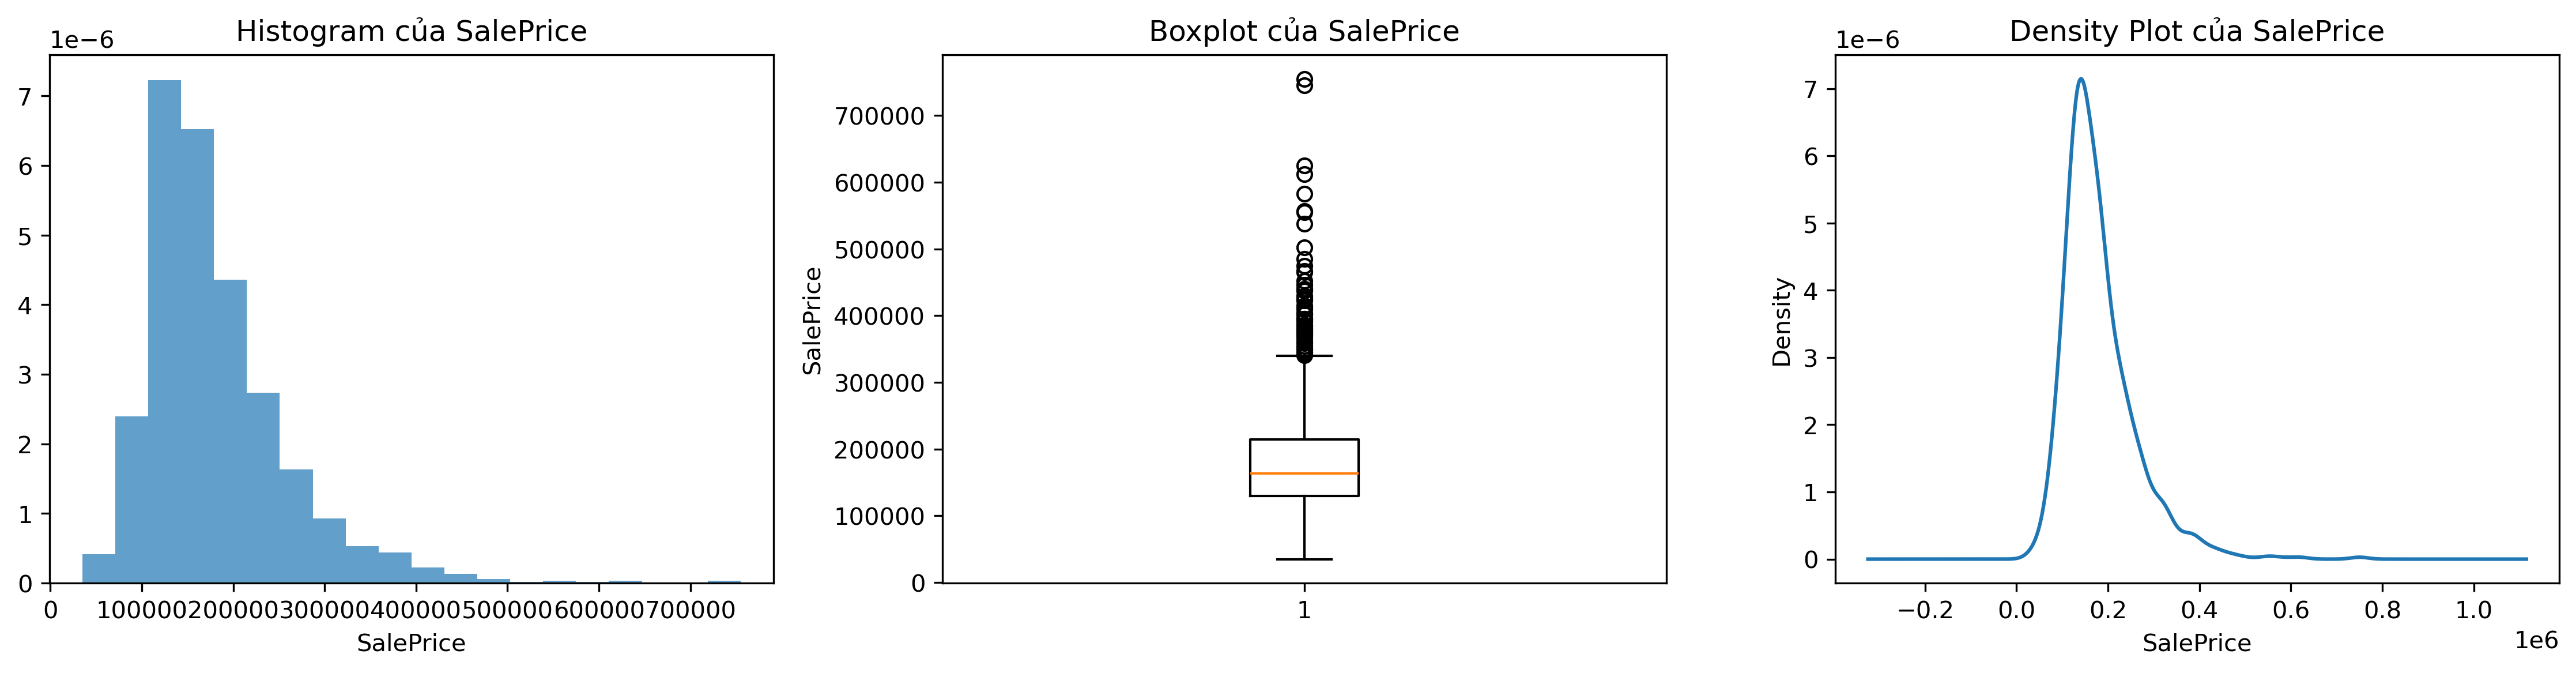

In [48]:
display.display(display.Image(filename='../eda/plots/SalePrice.png'))

In [49]:
print("Ratio of SalePrice > 500000:", len(df_train[df_train['SalePrice'] > 500000])/len(df_train))
display.display(df_train[df_train['SalePrice'] > 500000])

Ratio of SalePrice > 500000: 0.0061643835616438354


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
178,179,20,RL,63.0,17423,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,New,Partial,501837
440,441,20,RL,105.0,15431,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,555000
691,692,60,RL,104.0,21535,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2007,WD,Normal,755000
769,770,60,RL,47.0,53504,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,538000
803,804,60,RL,107.0,13891,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2009,New,Partial,582933
898,899,20,RL,100.0,12919,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,New,Partial,611657
1046,1047,60,RL,85.0,16056,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,New,Partial,556581
1169,1170,60,RL,118.0,35760,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,625000
1182,1183,60,RL,160.0,15623,Pave,NaN,IR1,Lvl,AllPub,...,555,Ex,MnPrv,NaN,0,7,2007,WD,Abnorml,745000


In [50]:
df_train = df_train[df_train['SalePrice'] < 500000].reset_index(drop=True)
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True).drop(columns=['Id'])

In [51]:
print("Combined data shape:", df.shape)
print(df.info())
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))
print(df.describe().T)

Combined data shape: (2910, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2910 entries, 0 to 2909
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     2910 non-null   int64  
 1   MSZoning       2906 non-null   object 
 2   LotFrontage    2424 non-null   float64
 3   LotArea        2910 non-null   int64  
 4   Street         2910 non-null   object 
 5   Alley          198 non-null    object 
 6   LotShape       2910 non-null   object 
 7   LandContour    2910 non-null   object 
 8   Utilities      2908 non-null   object 
 9   LotConfig      2910 non-null   object 
 10  LandSlope      2910 non-null   object 
 11  Neighborhood   2910 non-null   object 
 12  Condition1     2910 non-null   object 
 13  Condition2     2910 non-null   object 
 14  BldgType       2910 non-null   object 
 15  HouseStyle     2910 non-null   object 
 16  OverallQual    2910 non-null   int64  
 17  OverallCond    2910 

In [52]:
df[df['GarageYrBlt']==2207][['YearBuilt','YearRemodAdd']]

,YearBuilt,YearRemodAdd
2583,2006,2007


In [53]:
df.loc[df['GarageYrBlt'] == 2207,'GarageYrBlt']=2007

## Preprocessing

### Fill missing data

In [54]:
def preprocess_data(df, is_debug=False, params=None):
    df = df.copy()
    params = params or {}
    
    df.drop(columns=['PoolQC','MiscFeature','Fence'], inplace=True, errors='ignore')
    
    df['Alley'] = df.pop('Alley').notna().astype(int)

    # --- basic fills for 'no feature' semantics ---
    no_is_none = ['FireplaceQu','GarageType','GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond',
                  'BsmtExposure','BsmtFinType1','BsmtFinType2','MasVnrType','Electrical']
    for c in no_is_none:
        if c in df.columns:
            df[c] = df[c].fillna('None')
    # Areas that are 0 when no feature
    zero_if_na = ['MasVnrArea','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2',
                  'BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath','PoolArea',
                  'WoodDeckSF','OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch']
    for c in zero_if_na:
        if c in df.columns:
            df[c] = df[c].fillna(0)
    # LotFrontage: median per Neighborhood fallback to global median
    df['LotFrontage']=df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
    df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].median())
    # GarageYrBlt: if NA and GarageType == 'None' keep NA -> later flag; else fill with YearBuilt
    if 'GarageYrBlt' in df.columns:
        df['GarageYrBlt'] = df.apply(
            lambda row: row['YearBuilt'] if pd.isna(row['GarageYrBlt']) and row.get('GarageType','None') != 'None' else row['GarageYrBlt'] if not pd.isna(row['GarageYrBlt']) else 0,
            axis=1
        )
    # Impute some categoricals with mode
    cat_impute_mode = ['MSZoning','Utilities','Exterior1st','Exterior2nd','KitchenQual','SaleType','Functional']
    for c in cat_impute_mode:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].mode().iloc[0])
    
    if is_debug:
        print('After preprocessing: missing values sum =', df.isnull().sum().sum())
        print('Shape:', df.shape)
    return df

In [55]:
df = preprocess_data(df)

nan = df.isna().sum()
for col, cnt in nan.items():
    if cnt > 0:
        print(f'Column {col} has {cnt} missing values after preprocessing.')

Column SalePrice has 1459 missing values after preprocessing.


### Rare Encoding

In [56]:
from sklearn.preprocessing import LabelEncoder

rare_map = {
    'LandSlope':{'Rare':['Mod','Sev']},
    'HouseStyle':{'2Story':['2.5Fin']},
    'Condition2':{'Rare':['Artery','Feedr','RRAe','RRAn','RRNe']},
    'RoofStyle':{'Rare':['Flat','Mansard']},
    'RoofMatl':{'CompShg':['Tar&Grv'],'Rare_Roof':['Membran','Metal','Roll','WdShake','WdShngl','ClyTile']},
    'Exterior1st':{'Rare':['AsphShn','CBlock','AsbShng'],'Rare2':['Stucco','WdShing']},
    'Exterior2nd':{'Rare':['CBlock','AsphShn','Brk Cmn'],'Rare2':['Stone','Wd Shng']},
    'MasVnrType':{'Rare':['BrkCmn']},
    'Foundation':{'Rare':['Stone','Wood']},
    'Heating':{'Rare':['Floor','Grav','OthW','Wall']},
    'Electrical':{'Rare':['FuseP','Mix']},
    'Functional':{'Rare':['Min1','Min2','Maj1']},
    'GarageType':{'Rare':['2Types','Basment']},
    'SaleType':{'Rare':['New','Con'],'Rare2':['ConLI','CWD'],'Rare3':['ConLD','ConLw','Oth']},
    'SaleCondition':{'Rare':['Abnorml','Family'],'Normal':['Alloca']},
}
df['Street'] = LabelEncoder().fit_transform(df['Street'])
df.drop(['Utilities'],axis=1,inplace=True)

for col, mapping in rare_map.items():
    replace_dict={}
    for new_val,old_vals in mapping.items():
        for old in old_vals:
            replace_dict[old]=new_val
    df[col]=df[col].replace(replace_dict)

### Ordinal Encoding

In [57]:
qual_map_standard={'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1,'NaN':0}
bsmt_exposure_map={'Gd':4,'Av':3,'Mn':2,'No':1,'NaN':0}
bsmt_fin_map={'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NaN':0}
garage_finish_map={'Fin':3,'RFn':2,'Unf':1,'NaN':0}
paved_drive_map={'Y':2,'P':1,'N':0}
functional_map={'Typ':7,'Rare':5,'Mod':4,'Maj2':2,'Sev':1,'Sal':0}
central_air_map={'Y':1,'N':0}
neighborhood_map = {
    'NoRidge': 6, 'NridgHt': 6, 'StoneBr': 6,
    'Timber': 5, 'Veenker': 5, 'Somerst': 5,
    'Crawfor': 5, 'ClearCr': 5,
    'CollgCr': 4, 'Blmngtn': 4, 'Gilbert': 4, 'NWAmes': 4,
    'SawyerW': 4,
    'Mitchel': 3, 'NAmes': 3,
    'NPkVill': 2, 'SWISU': 2, 'Sawyer': 2,
    'OldTown': 2, 'Edwards': 2,
    'BrkSide': 1, 'BrDale': 1, 'IDOTRR': 1, 'MeadowV': 1, 'Blueste': 1
}



qual_cols_standard=['ExterQual','ExterCond','BsmtQual','BsmtCond','HeatingQC','KitchenQual','FireplaceQu','GarageQual','GarageCond']

for col in qual_cols_standard: 
    df[col]=df[col].replace(qual_map_standard)
df['BsmtExposure']=df['BsmtExposure'].replace(bsmt_exposure_map)
df['BsmtFinType1']=df['BsmtFinType1'].replace(bsmt_fin_map)
df['BsmtFinType2']=df['BsmtFinType2'].replace(bsmt_fin_map)
df['Functional']=df['Functional'].replace(functional_map)
df['GarageFinish']=df['GarageFinish'].replace(garage_finish_map)
df['PavedDrive']=df['PavedDrive'].replace(paved_drive_map)
df['CentralAir']=df['CentralAir'].replace(central_air_map)
df['Neighborhood']=df['Neighborhood'].replace(neighborhood_map)

## Feature engineering

In [58]:
# OverallQual/OverallCond already numeric but ensure int
df['OverallQual'] = df['OverallQual'].astype(int)
df['OverallCond'] = df['OverallCond'].astype(int)

# --- derived features ---
# Condition any normal
df['Condition_any_norm']=((df['Condition1']=='Norm')|(df['Condition2']=='Norm')).astype(int)

# Total living area
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# Total porch
porch_cols = ['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','WoodDeckSF']
df['TotalPorchSF'] = df[porch_cols].sum(axis=1)

# Total bathrooms (count half as 0.5)
fb = df.get('FullBath', 0)
bfb = df.get('BsmtFullBath', 0)
hb = df.get('HalfBath', 0)
bhb = df.get('BsmtHalfBath', 0)
df['TotalBath'] = fb + bfb + 0.5*(hb + bhb)

# Age features
df['HouseAge'] = (df['YrSold'] - df['YearBuilt']).clip(lower=0)
df['RemodAge'] = (df['YrSold'] - df['YearRemodAdd']).clip(lower=0)

# Garage age & flags
df['GarageAge'] = (df['YrSold'] - df['GarageYrBlt']).clip(lower=0)
df['HasGarage'] = (df['GarageType'] != 'None').astype(int)

# Basements / Pool / Fireplace flags
df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['HasMiscFeature']=(df['MiscVal']>0).astype(int)

# Masonry veneer flag
df['HasMasVnr'] = (df['MasVnrType'] != 'None').astype(int)

# New / Remodeled flags
df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['IsNew'] = (df['YearBuilt'] == df['YrSold']).astype(int)

## Chuẩn bị dữ liệu huấn luyện

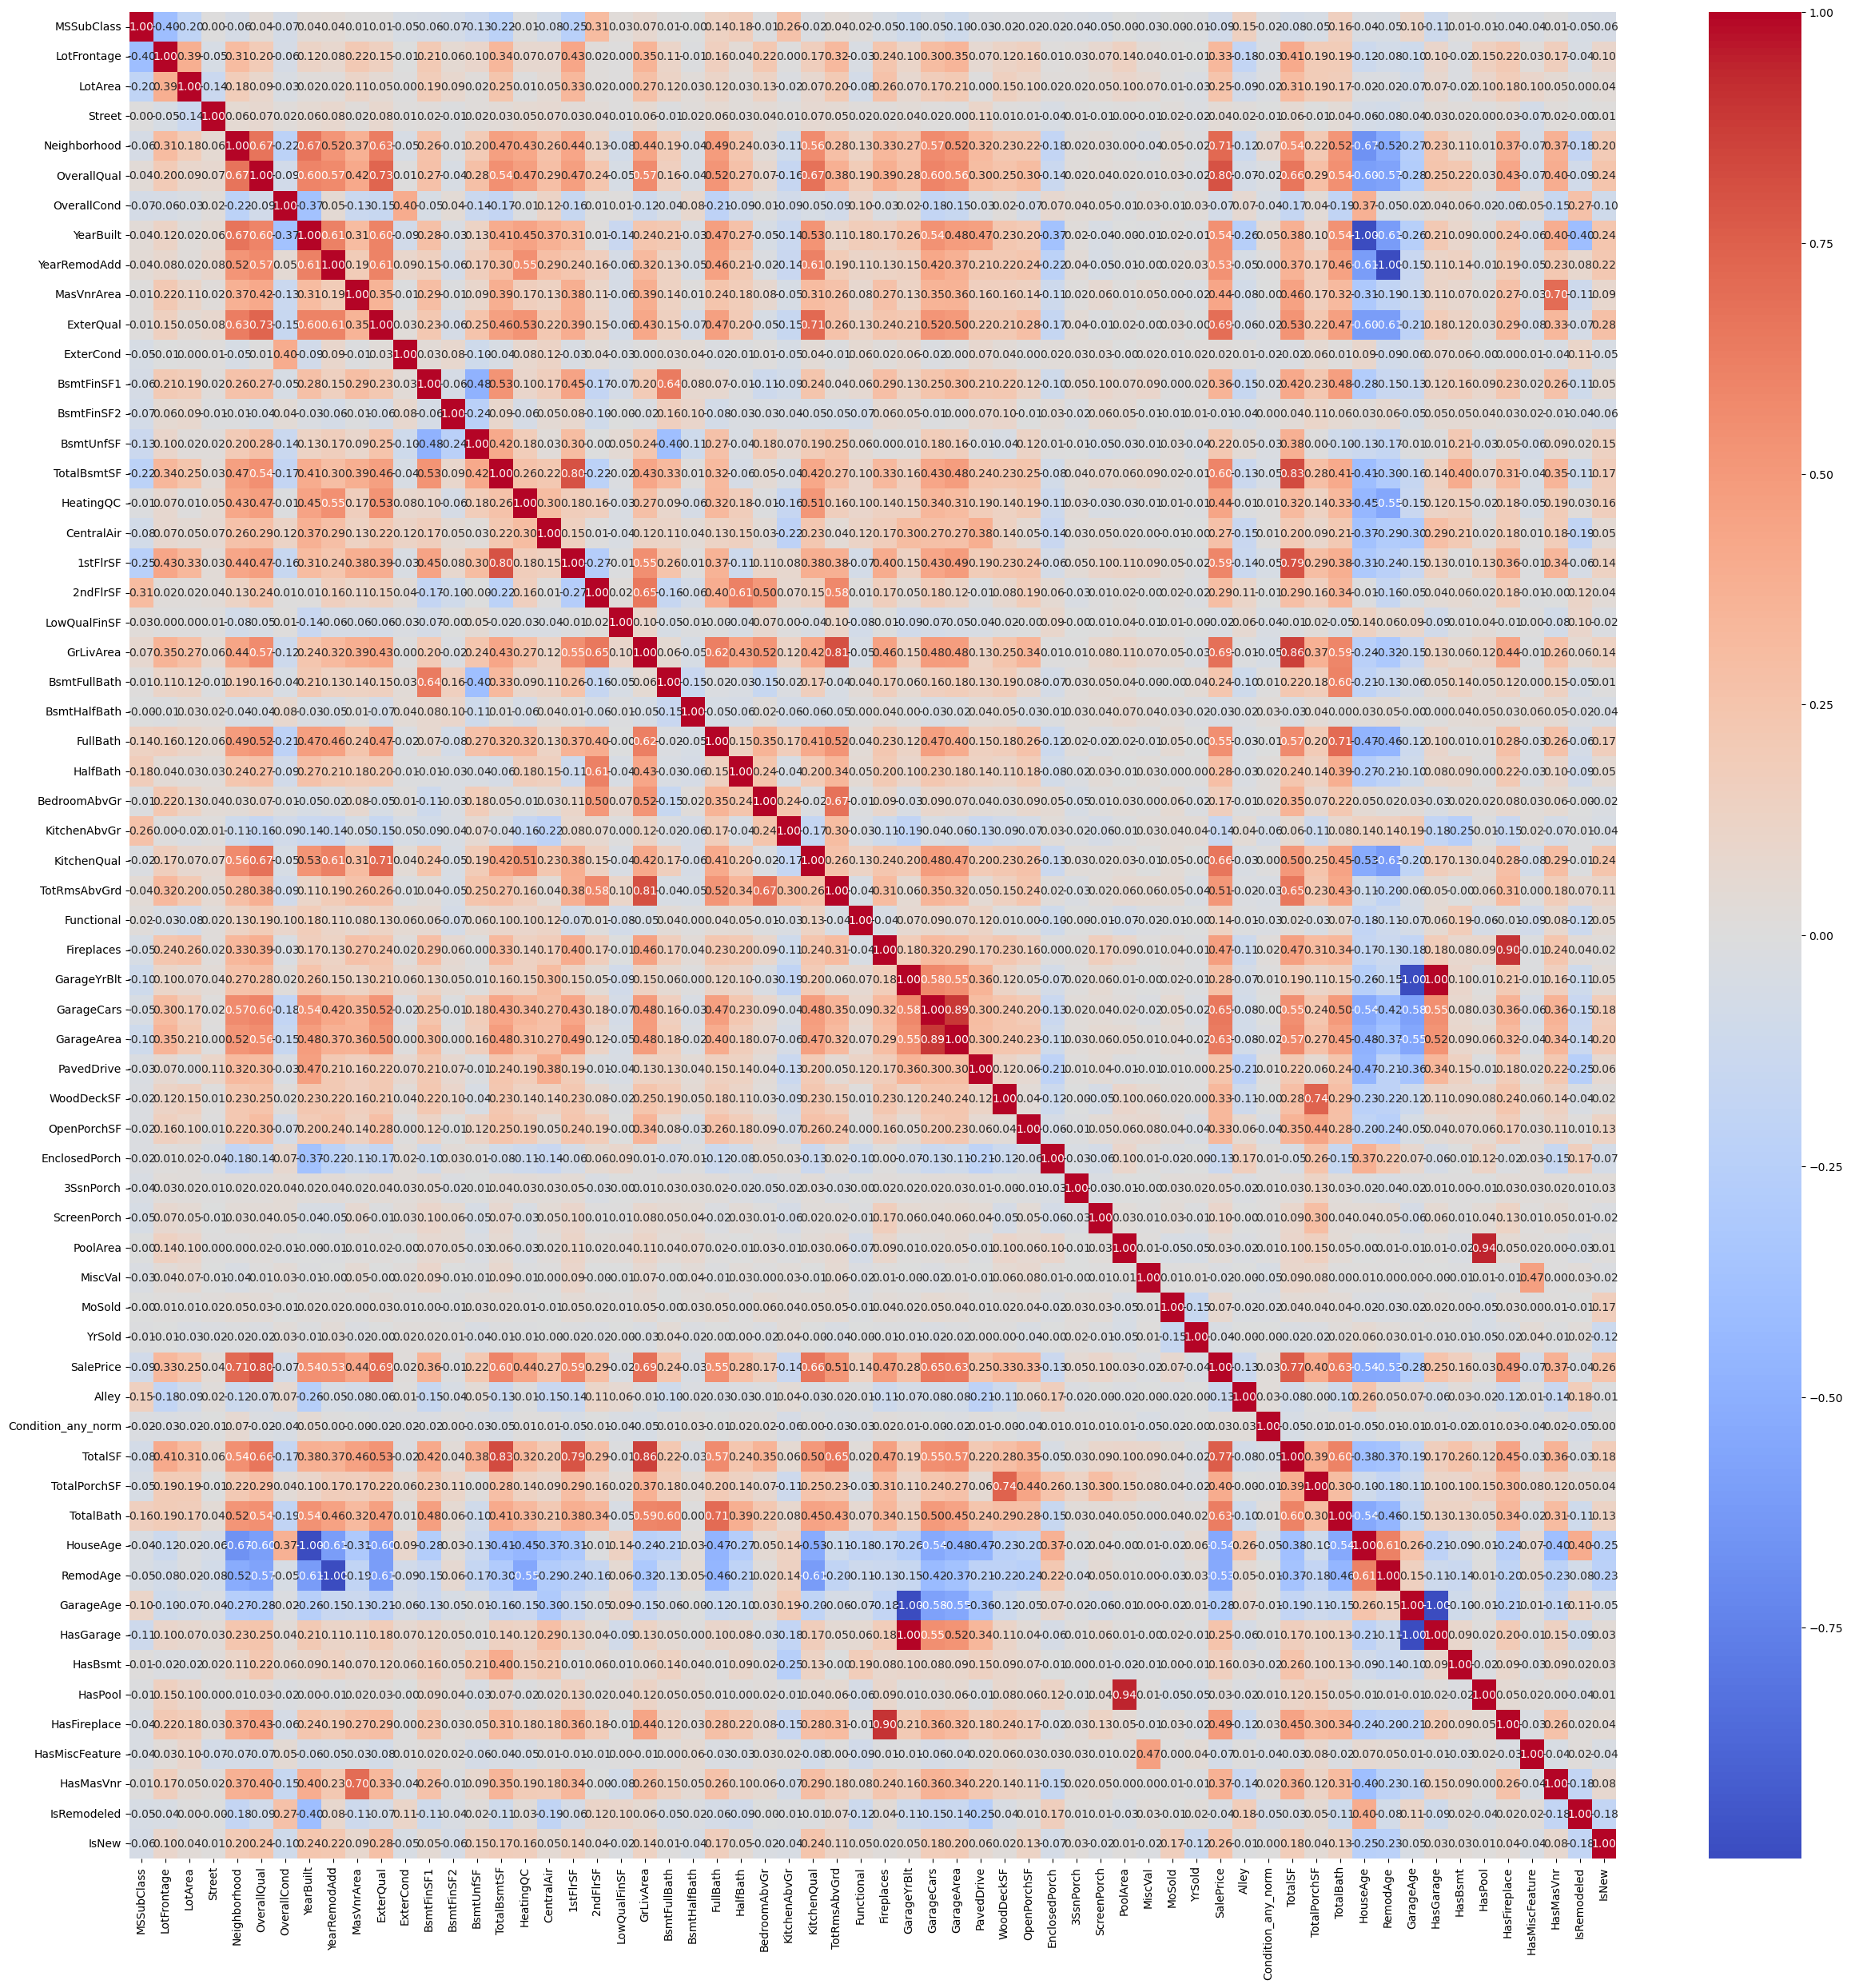

In [59]:
num_df = df.select_dtypes(include=[int,float])
plt.figure(figsize=(30, 30))
corr = num_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [60]:
print(corr['SalePrice'].sort_values(ascending=False))

SalePrice        1.000000
OverallQual      0.802424
TotalSF          0.765506
Neighborhood     0.711395
ExterQual        0.688569
                   ...   
EnclosedPorch   -0.129293
KitchenAbvGr    -0.142852
GarageAge       -0.279011
RemodAge        -0.534120
HouseAge        -0.544596
Name: SalePrice, Length: 62, dtype: float64


In [61]:
df_numeric = num_df.drop(columns=['SalePrice'])

corr_pairs = df_numeric.corr().unstack()
sorted_pairs_index = corr_pairs.index.map(lambda x: tuple(sorted(x)))
corr_pairs = corr_pairs[~sorted_pairs_index.duplicated()]
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

print('Top 10 strongest correlations (pairs)')
print(corr_pairs.sort_values(ascending=False).head(10))
print('\n\nTop 10 weakest correlations (pairs)')
print(corr_pairs.sort_values(ascending=True).head(10))

Top 10 strongest correlations (pairs)
GarageYrBlt  HasGarage       0.998494
PoolArea     HasPool         0.939411
Fireplaces   HasFireplace    0.900214
GarageCars   GarageArea      0.889543
GrLivArea    TotalSF         0.862623
TotalBsmtSF  TotalSF         0.826868
GrLivArea    TotRmsAbvGrd    0.807548
TotalBsmtSF  1stFlrSF        0.797312
1stFlrSF     TotalSF         0.789968
WoodDeckSF   TotalPorchSF    0.739083
dtype: float64


Top 10 weakest correlations (pairs)
GarageYrBlt   GarageAge   -0.999996
YearBuilt     HouseAge    -0.999061
GarageAge     HasGarage   -0.998489
YearRemodAdd  RemodAge    -0.998022
Neighborhood  HouseAge    -0.665111
KitchenQual   RemodAge    -0.613089
YearBuilt     RemodAge    -0.611879
YearRemodAdd  HouseAge    -0.608707
ExterQual     RemodAge    -0.607039
              HouseAge    -0.603881
dtype: float64


### Xóa bớt cột tương quan yếu hoặc có cột tương tự

In [62]:
cols_to_drop = [
    'YrSold','YearBuilt','YearRemodAdd','GarageYrBlt',
    'FullBath','HalfBath','BsmtFullBath','BsmtHalfBath',
    'OpenPorchSF','EnclosedPorch','WoodDeckSF','3SsnPorch','ScreenPorch',
    'GrLivArea','TotalBsmtSF','1stFlrSF','2ndFlrSF',
    'BsmtFinSF1','BsmtFinSF2','LotArea','GarageArea',
    'GarageCars','Condition1','Condition2',
    'PoolArea','MiscVal','LowQualFinSF',
    'Fireplaces','MoSold'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

### Log transform các cột numeric lệch

In [63]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_features:
    if col == 'SalePrice' or abs(df[col].skew()) > 0.75:
        df[col] = np.log1p(df[col])


### One-hot Encoding

In [64]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

### Tách train, test

In [65]:
print(df.shape)

df_train_processed = df[df['SalePrice'].notna()]
df_test_processed = df[df['SalePrice'].isna()].drop(columns=['SalePrice'])

(2910, 155)


## Model training

### Baseline

In [66]:
base_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Random Forest': RandomForestRegressor(random_state=params_cfg['seed']),
    'Gradient Boosting': GradientBoostingRegressor(random_state=params_cfg['seed']),
    'XGBoost': XGBRegressor(random_state=params_cfg['seed']),
    'LightGBM': LGBMRegressor(random_state=params_cfg['seed'], verbose=-1),
    'SVR': SVR(),
    'K-Neighbors': KNeighborsRegressor(),
    'CatBoost': CatBoostRegressor(random_state=params_cfg['seed'], verbose=False, allow_writing_files=False, train_dir=None)
}

In [67]:
kf = KFold(n_splits=params_cfg['k_folds'], shuffle=True, random_state=params_cfg['seed'])

for model_name, model in base_models.items():
    print(f"Training {model_name}...")
    for fold, (train_index, val_index) in enumerate(kf.split(df_train_processed)):
        
        X_train = df_train_processed.iloc[train_index].drop('SalePrice', axis=1)
        y_train = df_train_processed.iloc[train_index]['SalePrice']  # Series
        X_val = df_train_processed.iloc[val_index].drop('SalePrice', axis=1)
        y_val = df_train_processed.iloc[val_index]['SalePrice']     # Series
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        
        print(f"Fold {fold+1} - RMSE: {rmse:.4f}, R2: {r2:.4f}")

Training Linear Regression...
Fold 1 - RMSE: 0.1394, R2: 0.8739
Fold 2 - RMSE: 0.1344, R2: 0.8975
Fold 3 - RMSE: 0.1304, R2: 0.8775
Fold 4 - RMSE: 0.1631, R2: 0.8010
Fold 5 - RMSE: 0.1336, R2: 0.8769
Training Ridge...
Fold 1 - RMSE: 0.1383, R2: 0.8758
Fold 2 - RMSE: 0.1347, R2: 0.8970
Fold 3 - RMSE: 0.1241, R2: 0.8889
Fold 4 - RMSE: 0.1580, R2: 0.8132
Fold 5 - RMSE: 0.1254, R2: 0.8915
Training Lasso...
Fold 1 - RMSE: 0.3129, R2: 0.3646
Fold 2 - RMSE: 0.3321, R2: 0.3741
Fold 3 - RMSE: 0.2787, R2: 0.4400
Fold 4 - RMSE: 0.2834, R2: 0.3987
Fold 5 - RMSE: 0.2868, R2: 0.4326
Training ElasticNet...
Fold 1 - RMSE: 0.3078, R2: 0.3851
Fold 2 - RMSE: 0.3289, R2: 0.3861
Fold 3 - RMSE: 0.2762, R2: 0.4502
Fold 4 - RMSE: 0.2822, R2: 0.4038
Fold 5 - RMSE: 0.2841, R2: 0.4434
Training Random Forest...
Fold 1 - RMSE: 0.1458, R2: 0.8621
Fold 2 - RMSE: 0.1468, R2: 0.8778
Fold 3 - RMSE: 0.1424, R2: 0.8539
Fold 4 - RMSE: 0.1400, R2: 0.8534
Fold 5 - RMSE: 0.1252, R2: 0.8919
Training Gradient Boosting...
Fold 

### Tuning

In [68]:
param_grids = {
    'Linear Regression': {
        'fit_intercept': [True, False],
        'copy_X': [True, False],
        'positive': [False]  # Force positive coefficients
    },
    
    'Ridge': {
        'alpha': uniform(0.1, 10.0),
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']
    },
    
    'Lasso': {
        'alpha': uniform(0.001, 1.0),
        'max_iter': randint(1000, 5000)
    },
    
    'ElasticNet': {
        'alpha': uniform(0.001, 1.0),
        'l1_ratio': uniform(0.1, 0.9),
        'max_iter': randint(1000, 5000)
    },
    
    'Random Forest': {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 15, 20],
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(1, 5),
        'max_features': ['auto', 'sqrt', 'log2']
    },
    
    'Gradient Boosting': {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 8),
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(1, 5),
        'subsample': uniform(0.6, 0.4)  # 0.6 to 1.0
    },
    
    'XGBoost': {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 10),
        'min_child_weight': randint(1, 10),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    },
    
    'LightGBM': {
        'n_estimators': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 10),
        'num_leaves': randint(20, 100),
        'subsample': uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0, 1)
    },
    
    'SVR': {
        'C': uniform(0.1, 10),
        'gamma': ['scale', 'auto'] + list(uniform(0.001, 0.1).rvs(5)),
        'kernel': ['rbf', 'linear', 'poly']
    },
    
    'K-Neighbors': {
        'n_neighbors': randint(3, 15),
        'weights': ['uniform', 'distance'],
        'p': [1, 2]  # 1: manhattan, 2: euclidean
    },
    
    'CatBoost': {
        'iterations': randint(100, 500),
        'learning_rate': uniform(0.01, 0.3),
        'depth': randint(4, 10),
        'l2_leaf_reg': uniform(1, 10),
        'subsample': uniform(0.6, 0.4)
    }
}

In [70]:
rmse_results = {}
best_models = {}

for model_name in base_models.keys():
    print(f"\nTuning {model_name}...")
    
    # Lấy model và param grid
    model = base_models[model_name]
    param_grid = param_grids[model_name]
    
    # RandomizedSearchCV
    random_search = RandomizedSearchCV(
        model,
        param_grid,
        n_iter=10,
        cv=5,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1
    )
    
    # Fit toàn bộ data
    X = df_train_processed.drop(columns='SalePrice', axis=1)
    y = df_train_processed['SalePrice']
    
    random_search.fit(X, y)
    
    # In kết quả
    best_rmse = -random_search.best_score_
    print(f"- Best RMSE: {best_rmse:.4f}")
    print(f"- Best params: {random_search.best_params_}")

    # Lưu kết quả
    rmse_results[model_name] = best_rmse
    best_models[model_name] = random_search.best_estimator_


Tuning Linear Regression...
- Best RMSE: 0.1431
- Best params: {'positive': False, 'fit_intercept': True, 'copy_X': True}

Tuning Ridge...
- Best RMSE: 0.1333
- Best params: {'alpha': 7.319987722668247, 'solver': 'svd'}

Tuning Lasso...
- Best RMSE: 0.1319
- Best params: {'alpha': 0.0017787658410143284, 'max_iter': 1955}

Tuning ElasticNet...
- Best RMSE: 0.1321
- Best params: {'alpha': 0.008066305219717407, 'l1_ratio': 0.12075618253727419, 'max_iter': 1474}

Tuning Random Forest...
- Best RMSE: 0.1425
- Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 291}

Tuning Gradient Boosting...
- Best RMSE: 0.1237
- Best params: {'learning_rate': 0.02393512381599932, 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 428, 'subsample': 0.6260206371941118}

Tuning XGBoost...
- Best RMSE: 0.1242
- Best params: {'colsample_bytree': 0.6727299868828402, 'learning_rate': 0.06502135295603015, 'max_depth': 

In [71]:
os.makedirs(params_cfg['save_dir'], exist_ok=True)

# Lưu models
for model_name, model in best_models.items():
    filename = f"{model_name.replace(' ', '_').lower()}_best_model.pkl"
    filepath = os.path.join(params_cfg['save_dir'], filename)
    joblib.dump(model, filepath)
    print(f"Saved: {filename}")

Saved: linear_regression_best_model.pkl
Saved: ridge_best_model.pkl
Saved: lasso_best_model.pkl
Saved: elasticnet_best_model.pkl
Saved: random_forest_best_model.pkl
Saved: gradient_boosting_best_model.pkl
Saved: xgboost_best_model.pkl
Saved: lightgbm_best_model.pkl
Saved: svr_best_model.pkl
Saved: k-neighbors_best_model.pkl
Saved: catboost_best_model.pkl


In [72]:
# Tìm model tốt nhất
best_model_name = min(rmse_results, key=rmse_results.get)
best_model = best_models[best_model_name]

print(f"\nBEST MODEL: {best_model_name}")
print(f"Best RMSE: {rmse_results[best_model_name]:.4f}")

# Hiển thị ranking tất cả models
print("\nMODEL RANKING:")
for model_name, rmse in sorted(rmse_results.items(), key=lambda x: x[1]):
    print(f"{model_name:20}: {rmse:.4f}")


BEST MODEL: CatBoost
Best RMSE: 0.1219

MODEL RANKING:
CatBoost            : 0.1219
Gradient Boosting   : 0.1237
XGBoost             : 0.1242
LightGBM            : 0.1251
Lasso               : 0.1319
ElasticNet          : 0.1321
SVR                 : 0.1328
Ridge               : 0.1333
Random Forest       : 0.1425
Linear Regression   : 0.1431
K-Neighbors         : 0.1873


## Submit

### Dự đoán các mô hình đơn lẻ

In [73]:
for model in best_models.values():
    model.fit(
        df_train_processed.drop(columns=['SalePrice'], axis=1),
        df_train_processed['SalePrice']
    )

    y_test_pred = np.expm1(model.predict(df_test_processed))
    df_submission = pd.DataFrame({
        'Id': df_test['Id'],
        'SalePrice': y_test_pred
    })

    df_submission.to_csv(f"{params_cfg['save_dir']}/submission_{model.__class__.__name__}.csv", index=False)

### Ensemble: Stacking + Weighted Average

In [77]:
# Ensemble: stacking + weighted average (chèn trước cell "Submit")
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# Prepare data
X = df_train_processed.drop(columns=['SalePrice'])
y = df_train_processed['SalePrice']
X_test = df_test_processed.copy()

# Build estimators list from best_models
estimators = [(n.replace(' ', '_'), m) for n, m in best_models.items()]

# 1) Stacking ensemble
stack = StackingRegressor(estimators=estimators, final_estimator=Ridge(random_state=params_cfg['seed']), n_jobs=-1, passthrough=False)
stack.fit(X, y)
joblib.dump(stack, os.path.join(params_cfg['save_dir'], 'stacking_regressor.pkl'))

y_stack = np.expm1(stack.predict(X_test))  # inverse of log1p
pd.DataFrame({'Id': df_test['Id'], 'SalePrice': y_stack}).to_csv(os.path.join(params_cfg['save_dir'], 'submission_stacking.csv'), index=False)

# 2) Weighted average ensemble (weights = normalized inverse RMSE)
# ensure rmse_results available and >0
inv_weights = {name: 1.0 / max(rmse_results[name], 1e-8) for name in rmse_results}
total = sum(inv_weights.values())
weights = {name: inv_weights[name] / total for name in inv_weights}

# Re-fit base models on full training (helps if some estimators were not refit)
preds = []
for name, model in best_models.items():
    model.fit(X, y)
    preds.append(weights[name] * np.expm1(model.predict(X_test)))

y_weighted = np.sum(preds, axis=0)
pd.DataFrame({'Id': df_test['Id'], 'SalePrice': y_weighted}).to_csv(os.path.join(params_cfg['save_dir'], 'submission_weighted_avg.csv'), index=False)

print('Saved ensemble models and submissions: stacking + weighted_avg')

Saved ensemble models and submissions: stacking + weighted_avg
